In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


In [2]:
img_path = "images/coca_logo_1.png"

template_path = "template/pattern.png"

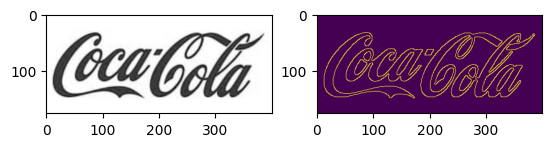

In [3]:
# Procesamos template

template_img = cv.imread(template_path,0)
template_edges = cv.Canny(template_img,100,200)


plt.figure()
plt.subplot(1,2,1)
plt.imshow(template_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(template_edges)
plt.show()


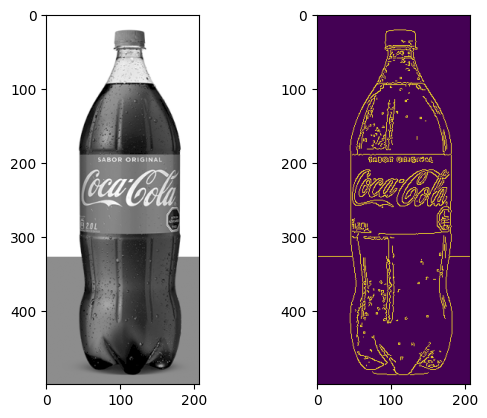

In [4]:
img_grayscale = cv.imread(img_path,0)
image_edges = cv.Canny(img_grayscale,100,200)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(img_grayscale, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(image_edges)
plt.show()

In [5]:
resize_percentaje = 25

In [6]:
max_dim = np.argmax(template_edges.shape)

scale_factor = ((img_grayscale.shape[max_dim]*resize_percentaje/100)/template_edges.shape[max_dim])

# Resize the image (scaling down)
resized_down_template = cv.resize(template_img, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)


edges = cv.Canny(resized_down_template,100,200)
 


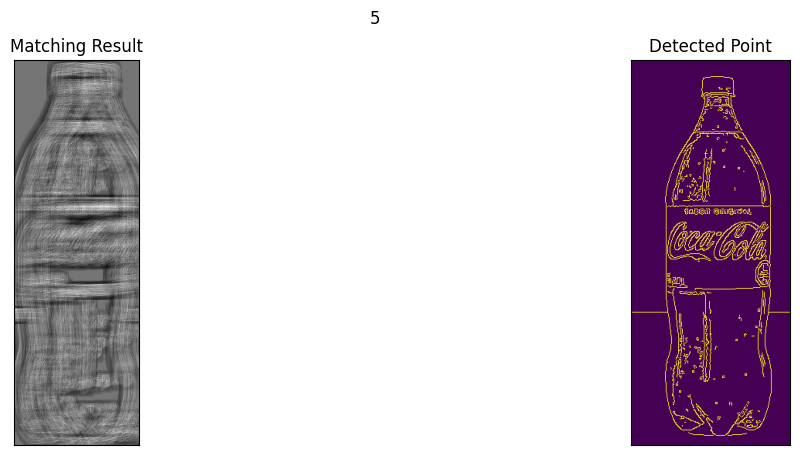

(500, 207)


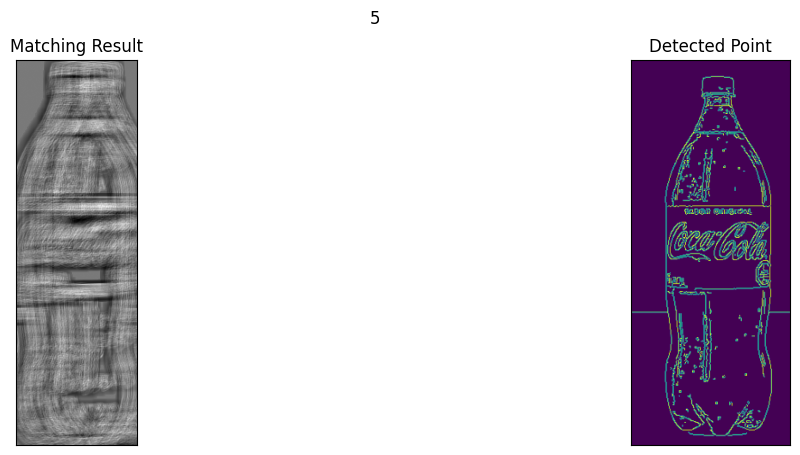

(450, 186)


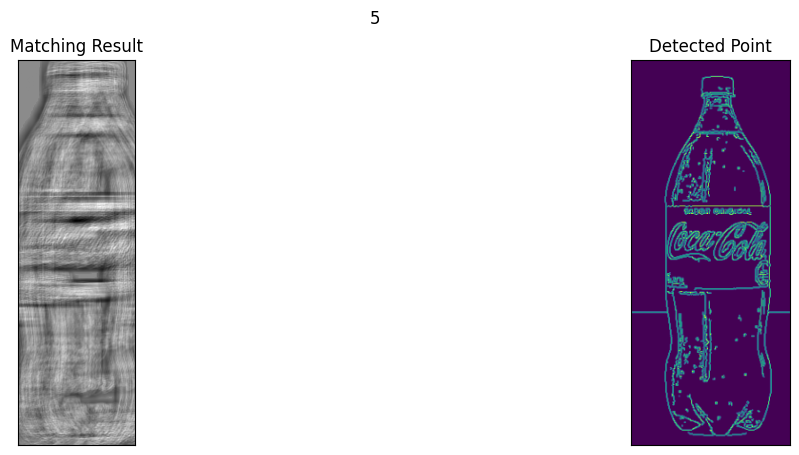

(405, 167)


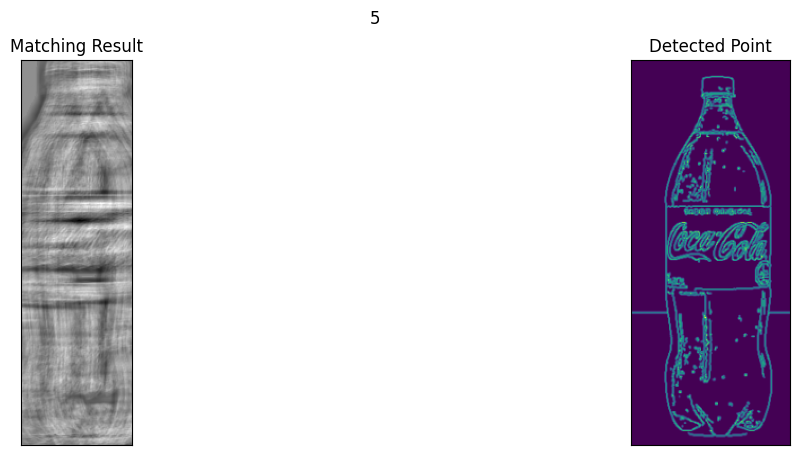

(364, 150)


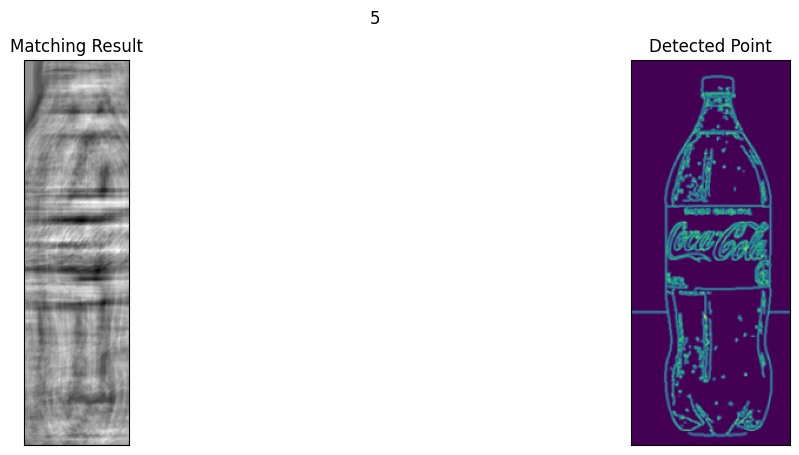

(328, 135)


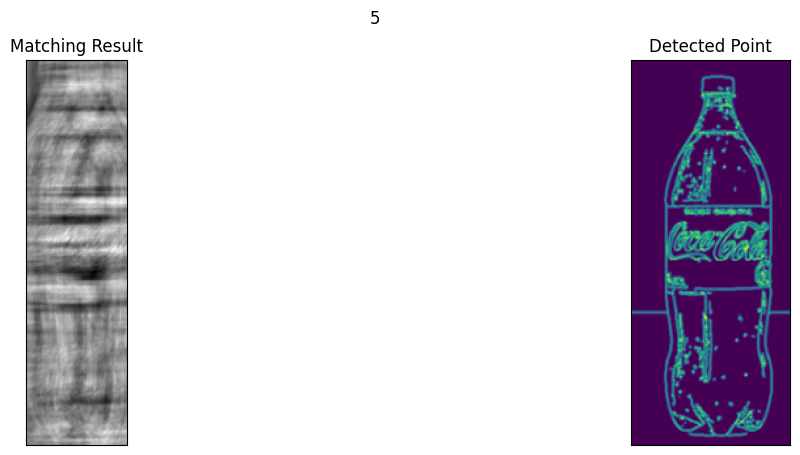

(295, 122)


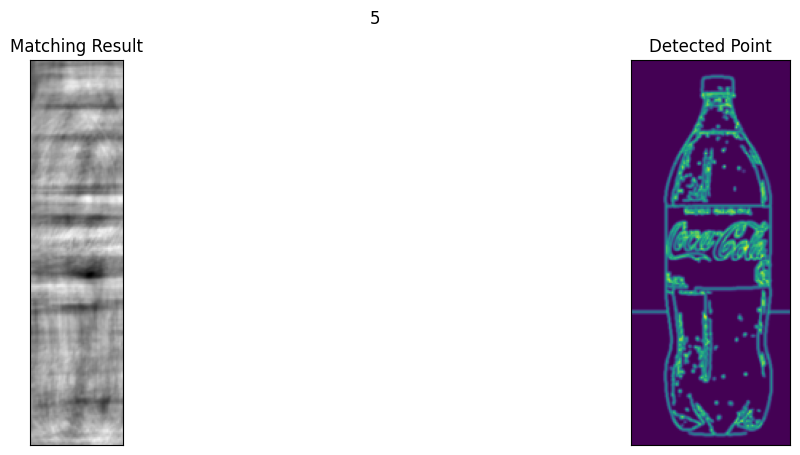

(266, 110)


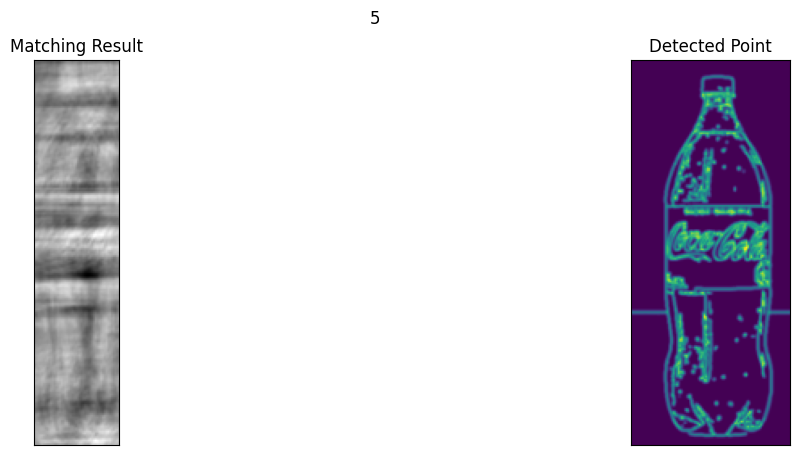

(239, 99)


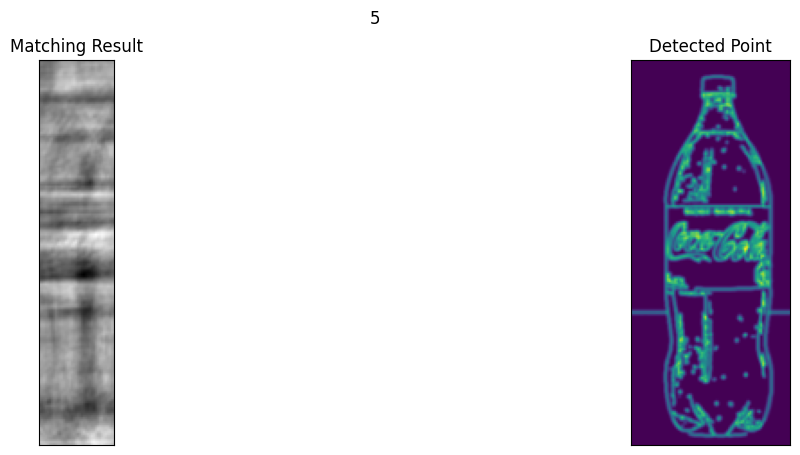

(215, 89)


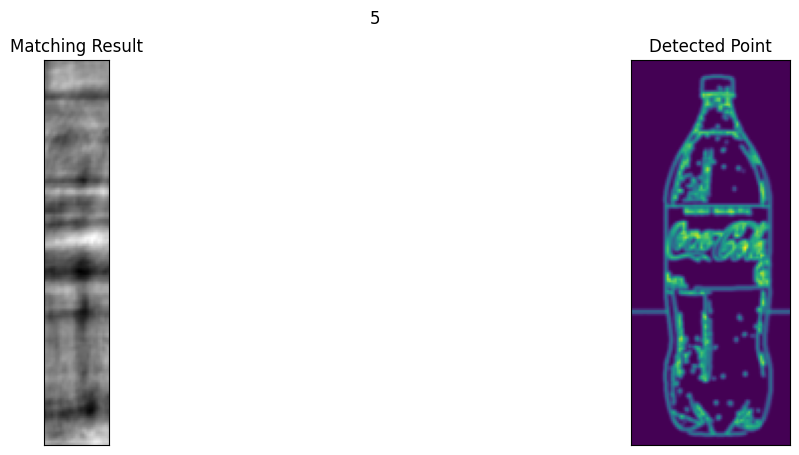

(194, 80)


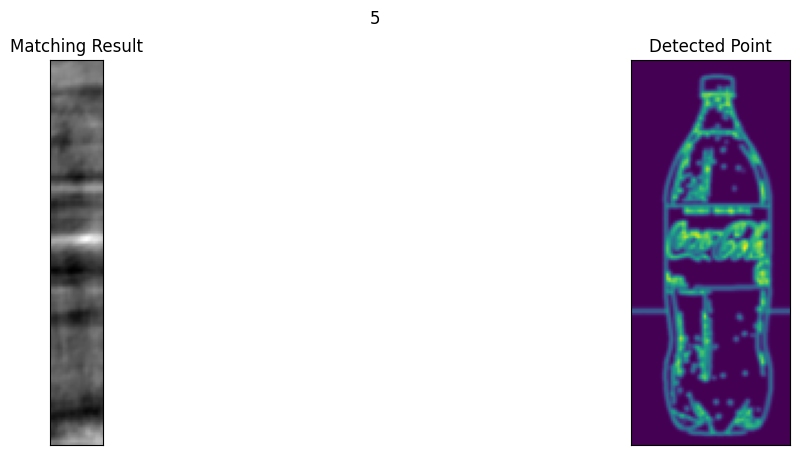

(175, 72)


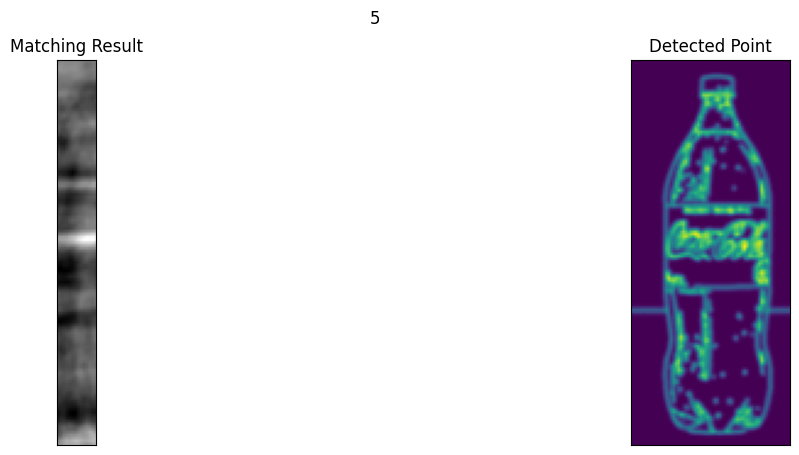

(158, 65)


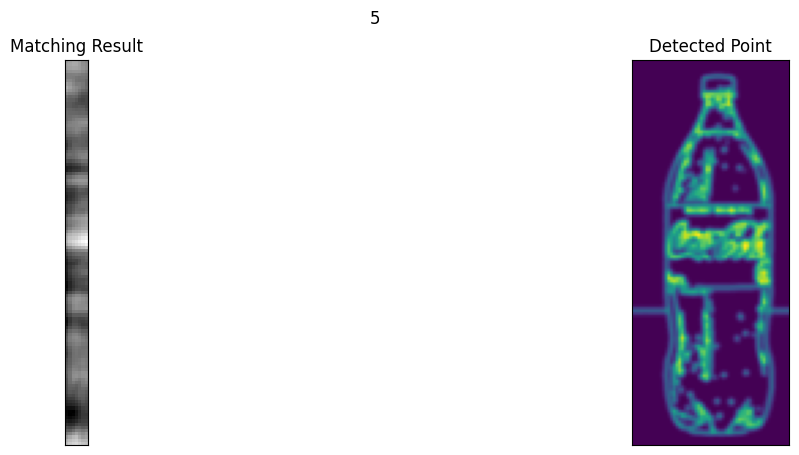

(142, 58)


In [7]:
current_image = image_edges.copy()



while (current_image.shape[0] > edges.shape[0]) and (current_image.shape[1] > edges.shape[1]):

    img_show = current_image.copy()

    method = eval('cv.TM_CCOEFF_NORMED')


    #current_edges = cv.Canny(current_image,100,200)

    res = cv.matchTemplate(current_image, edges, method)

    # Encontramos los valores máximos y mínimos
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    w, h = edges.shape[::-1]

    threshold = 0.4

    loc = np.where( res >= threshold)
    for pt in zip(*loc[::-1]):
        cv.rectangle(img_show, pt, (pt[0] + w, pt[1] + h), (0,0,0), 2)

    # Graficamos el procesamiento y la salida
    #----------------------------------------
    plt.figure(figsize=(15, 5))
    # Resultado de coincidencia
    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

    # Imagen original con recuadros
    plt.subplot(122),plt.imshow(img_show)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

    #plt.subplot(133),plt.imshow(current_edges,cmap='grey')
    #plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

    plt.suptitle(method)
    plt.show()
    
    print(current_image.shape)
    current_image = cv.resize(current_image, None, fx=0.9, fy=0.9, interpolation=cv.INTER_AREA).copy()
    #cv.imshow('Downscaled', current_image)
    #cv.waitKey(500)

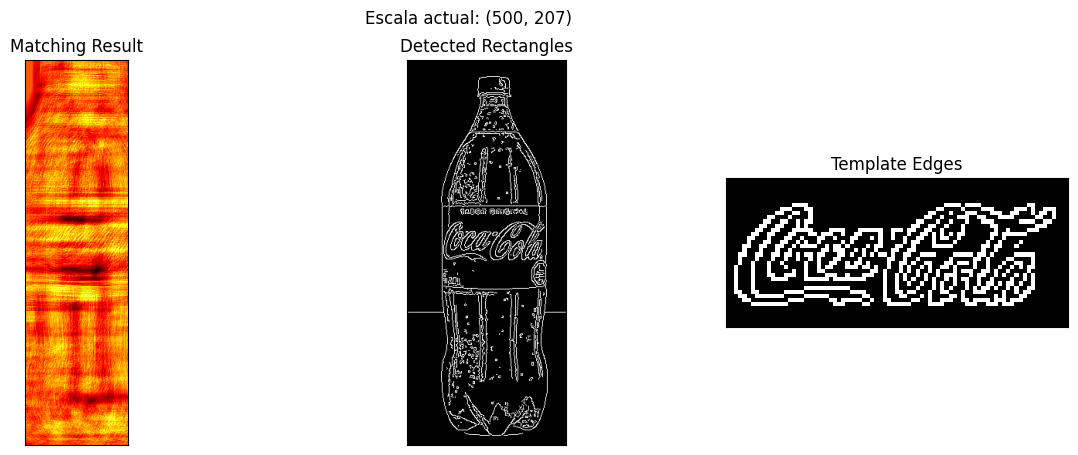

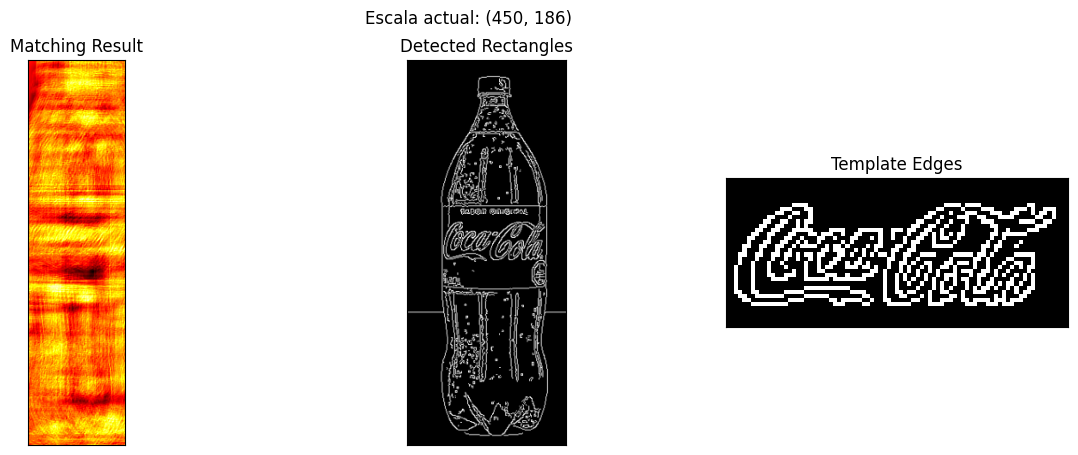

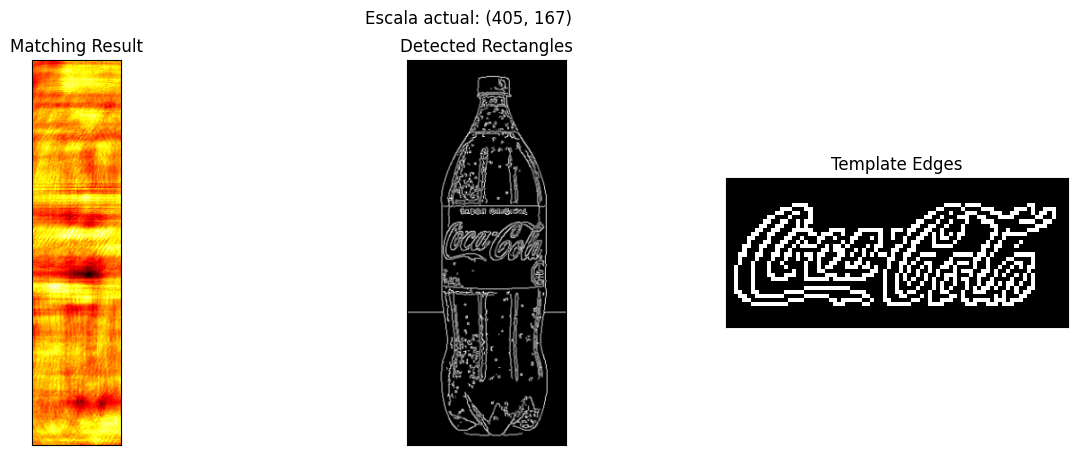

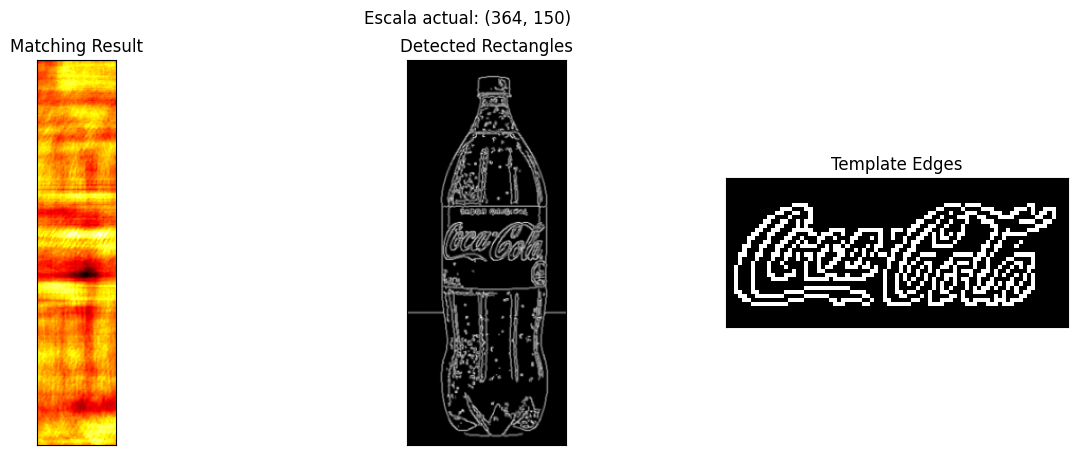

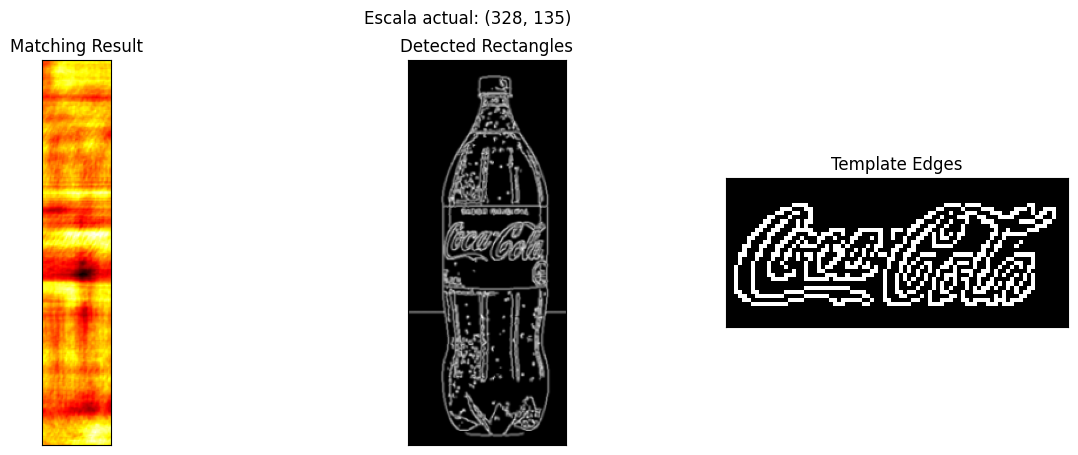

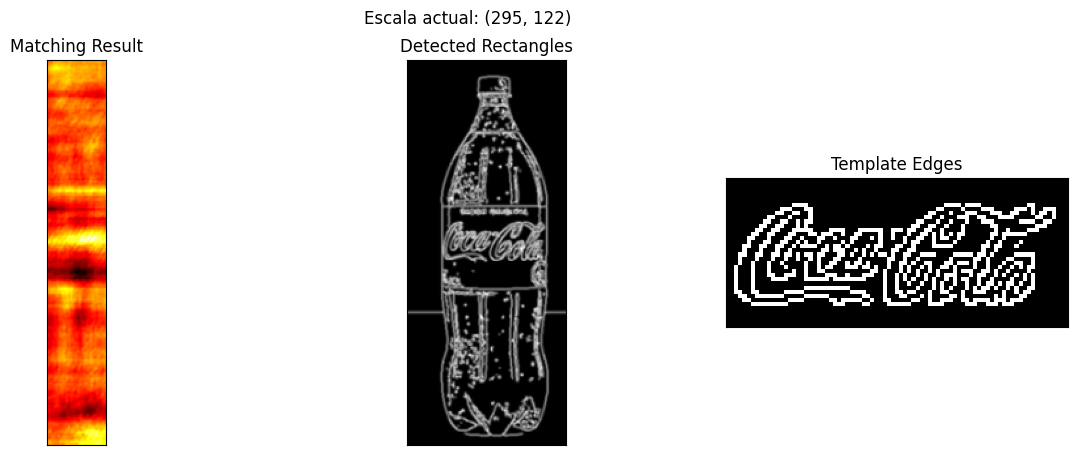

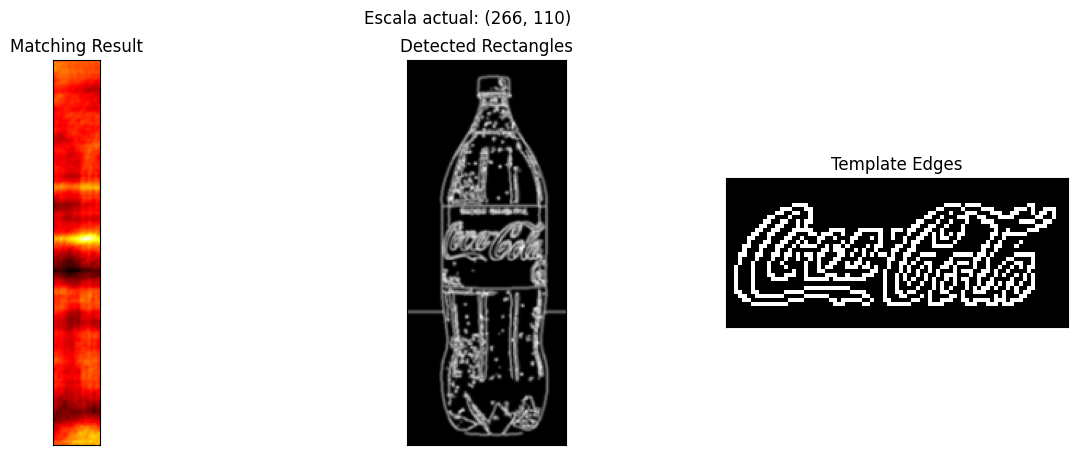

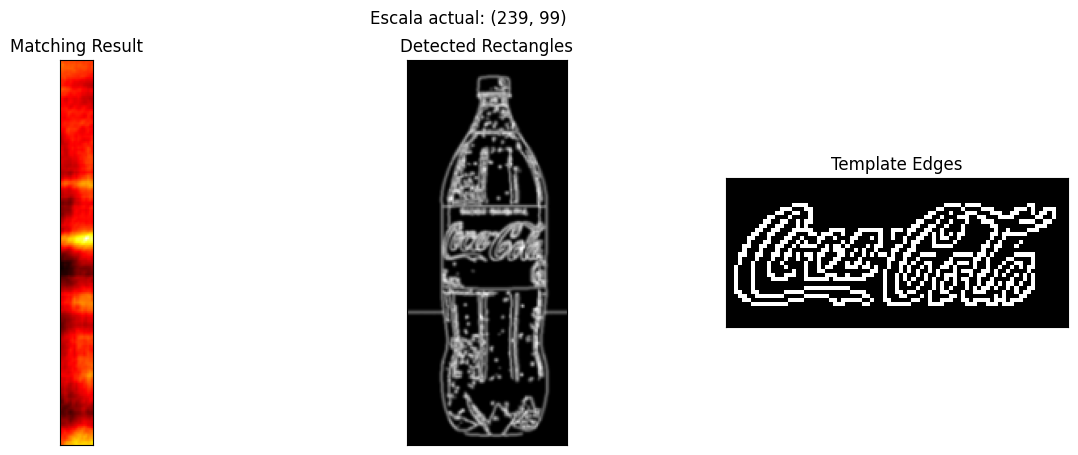

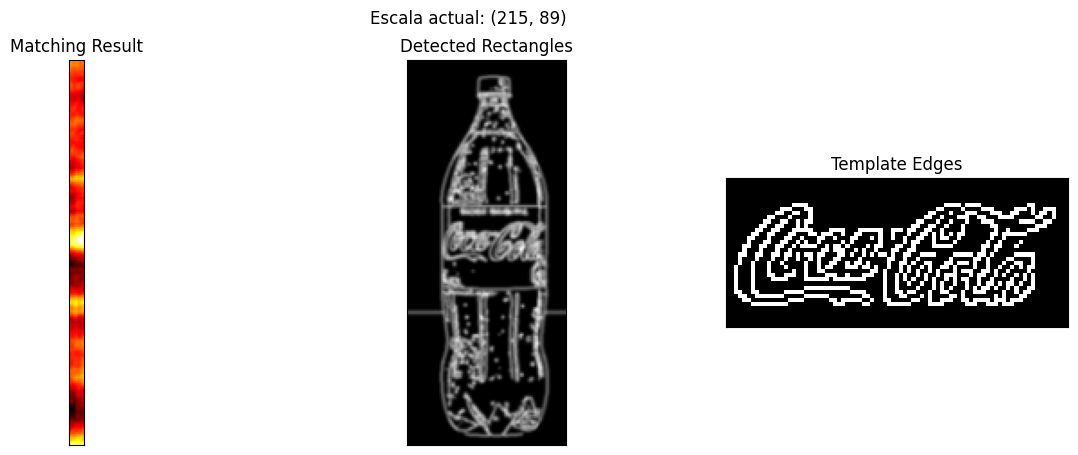

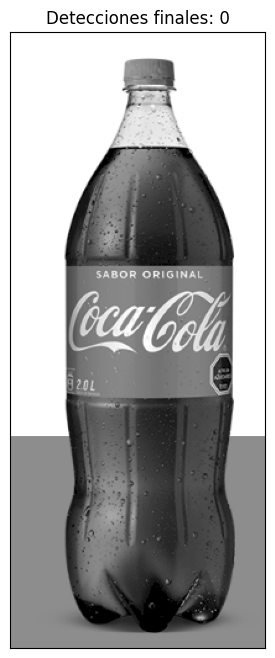

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ======================
# CONFIGURACIÓN INICIAL
# ======================
resize_percentage = 40
threshold = 0.4
scale_step = 0.90  # Reducción por iteración
min_scale_size = 0.2  # Tamaño mínimo relativo del template vs imagen

method = cv.TM_CCOEFF_NORMED

# ======================
# PREPROCESAMIENTO
# ======================

# Escalamos la plantilla según porcentaje deseado
max_dim = np.argmax(template_edges.shape)
scale_factor = ((img_grayscale.shape[max_dim] * resize_percentage / 100) /
                template_edges.shape[max_dim])

# Redimensionar plantilla
resized_template = cv.resize(template_img, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)

# Usar bordes de la plantilla para matching
template_edges = cv.Canny(resized_template, 100, 200)
w, h = template_edges.shape[::-1]

# Imagen de trabajo (imagen completa con bordes)
current_image = image_edges.copy()

# Detecciones acumuladas: [(x1, y1, x2, y2, score)]
detections = []

# ======================
# ESCALADO MULTINIVEL
# ======================

while (current_image.shape[0] >= template_edges.shape[0] and
       current_image.shape[1] >= template_edges.shape[1]):

    img_show = current_image.copy()

    # Matching con bordes
    res = cv.matchTemplate(current_image, template_edges, method)

    # Umbral para detecciones múltiples
    loc = np.where(res >= threshold)

    for pt in zip(*loc[::-1]):
        x1, y1 = pt
        x2, y2 = x1 + w, y1 + h
        score = res[y1, x1]
        detections.append((x1, y1, x2, y2, score))
        cv.rectangle(img_show, (x1, y1), (x2, y2), (255, 255, 255), 2)

    # Visualización intermedia
    plt.figure(figsize=(15, 5))
    plt.subplot(131), plt.imshow(res, cmap='hot')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(132), plt.imshow(img_show, cmap='gray')
    plt.title('Detected Rectangles'), plt.xticks([]), plt.yticks([])
    plt.subplot(133), plt.imshow(template_edges, cmap='gray')
    plt.title('Template Edges'), plt.xticks([]), plt.yticks([])
    plt.suptitle(f"Escala actual: {current_image.shape}")
    plt.show()

    # Escalamos la imagen hacia abajo para la siguiente iteración
    current_image = cv.resize(current_image, None, fx=scale_step, fy=scale_step, interpolation=cv.INTER_AREA)

    # Cortamos si ya es más chica que la plantilla
    if current_image.shape[0] < h or current_image.shape[1] < w:
        break

# ======================
# SUPRESIÓN BÁSICA DE DUPLICADOS (tipo NMS)
# ======================
def non_max_suppression_fast(detections, iou_thresh=0.3):
    if len(detections) == 0:
        return []

    boxes = np.array(detections)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    scores = boxes[:, 4]

    indices = np.argsort(scores)[::-1]
    keep = []

    while len(indices) > 0:
        i = indices[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[indices[1:]])
        yy1 = np.maximum(y1[i], y1[indices[1:]])
        xx2 = np.minimum(x2[i], x2[indices[1:]])
        yy2 = np.minimum(y2[i], y2[indices[1:]])

        inter_w = np.maximum(0, xx2 - xx1)
        inter_h = np.maximum(0, yy2 - yy1)
        inter_area = inter_w * inter_h

        box_area = (x2[indices[1:]] - x1[indices[1:]]) * (y2[indices[1:]] - y1[indices[1:]])
        iou = inter_area / (box_area + (x2[i] - x1[i]) * (y2[i] - y1[i]) - inter_area)

        indices = indices[1:][iou < iou_thresh]

    return boxes[keep].astype(int)

# ======================
# VISUALIZACIÓN FINAL
# ======================
img_final = img_grayscale.copy()
detections_nms = non_max_suppression_fast(detections)

for (x1, y1, x2, y2, score) in detections_nms:
    cv.rectangle(img_final, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv.putText(img_final, f"{score:.2f}", (x1, y1 - 5),
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(12, 8))
plt.imshow(img_final, cmap='gray')
plt.title(f'Detecciones finales: {len(detections_nms)}')
plt.xticks([]), plt.yticks([])
plt.show()


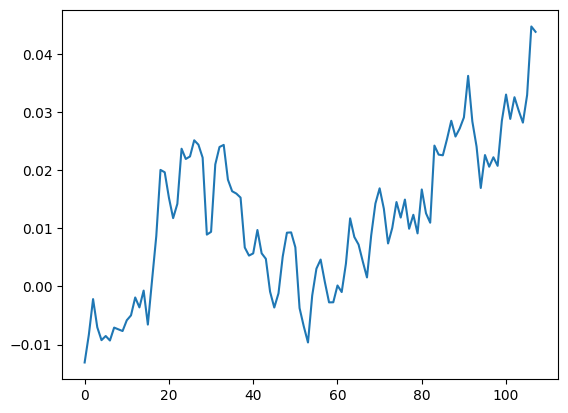

In [150]:
plt.plot(res[:,4])

In [41]:
resized_down.shape

(23, 52)

In [35]:
# Resize the image (scaling down)
resized_down = cv.resize(template_edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_LINEAR)
 
 
# Display the images
cv.imshow("Original Image", template_edges)
cv.imshow("Scaled Down Image", resized_down)
cv.waitKey(0)
cv.destroyAllWindows()


In [52]:
scale_factor**(-1)

20.0

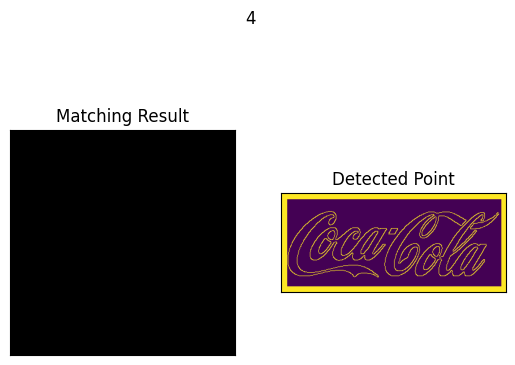

In [ ]:
method = eval('cv.TM_CCOEFF')

res = cv.matchTemplate(edges, edges, method)

# Encontramos los valores máximos y mínimos
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

w, h = edges.shape[::-1]

top_left = max_loc

bottom_right = (top_left[0] + w, top_left[1] + h)

cv.rectangle(edges,top_left, bottom_right, 255, 20)

# Graficamos el procesamiento y la salida
#----------------------------------------
plt.figure()

# Resultado de coincidencia
plt.subplot(121),plt.imshow(res,cmap = 'gray')
plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

# Imagen original con recuadros
plt.subplot(122),plt.imshow(edges)
plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

plt.suptitle(method)
plt.show()

In [9]:
res

array([[3.662694e+08]], dtype=float32)

In [7]:
edges.shape

(175, 400)

In [6]:
bottom_right

(400, 175)

In [8]:
np.max(res)

np.float32(3.662694e+08)

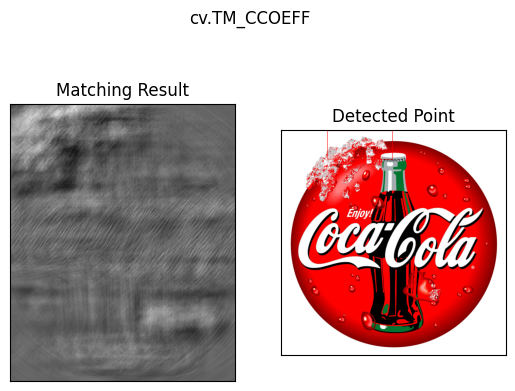

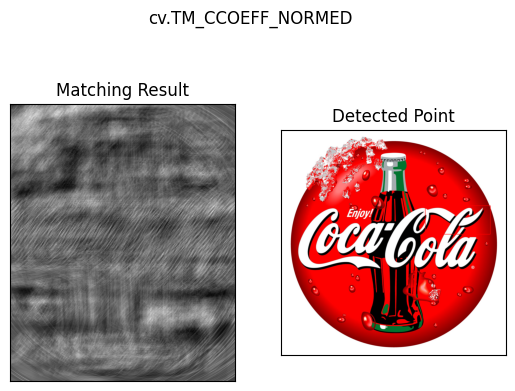

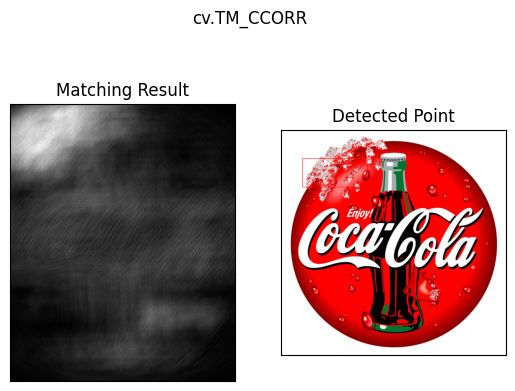

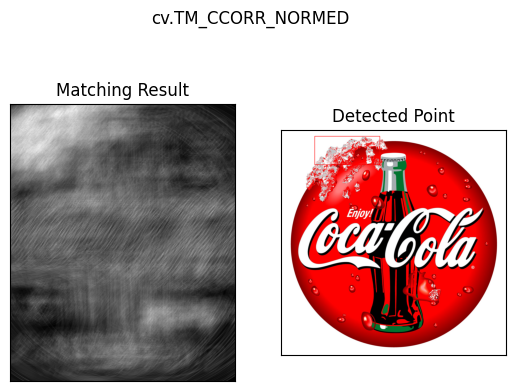

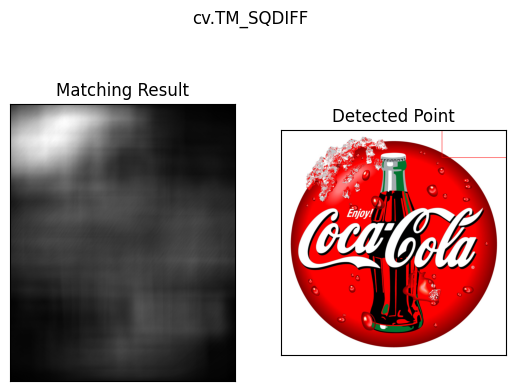

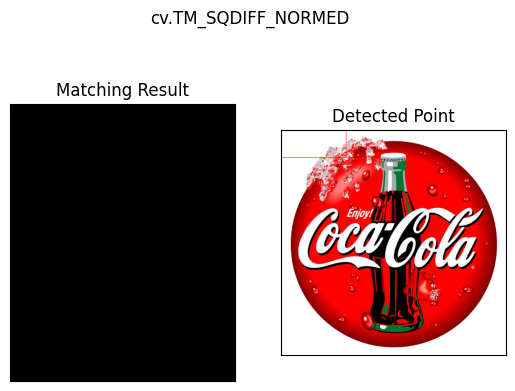

In [7]:
w, h = template.shape[::-1]
# Los 6 métodos posibles para comparación:
methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
            'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

for meth in methods:
    # Hago una copia de la imagen porque ciclo a ciclo le dibujo rectángulos
    img_salida = img_rgb.copy()
    
    method = eval(meth)
    

    edges_logo = edges

    img_edges = cv.Canny(img_gray,100,200)


    # Aplicamos la coincidencia de patrones
    #--------------------------------------
    res = cv.matchTemplate(img_edges, edges_logo, method)
    
    # Encontramos los valores máximos y mínimos
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
    
    # Si el método es TM_SQDIFF o TM_SQDIFF_NORMED, tomamos el mínimo
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    
    # Marcamos el lugar donde lo haya encontrado
    #----------------------------------------
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv.rectangle(img_salida,top_left, bottom_right, 255, 2)
    
    # Graficamos el procesamiento y la salida
    #----------------------------------------
    plt.figure()
    
    # Resultado de coincidencia
    plt.subplot(121),plt.imshow(res,cmap = 'gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    
    # Imagen original con recuadros
    plt.subplot(122),plt.imshow(img_salida)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    
    plt.suptitle(meth)
    plt.show()